In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("imports ok")

imports ok


In [2]:
train_df = pd.read_csv('../data/train_clean.csv')
test_df = pd.read_csv('../data/test_clean.csv')

X_train = train_df['clean_text']
y_train = train_df['label']

X_test = test_df['clean_text']
y_test = test_df['label']

print(X_train.shape, X_test.shape)

(25000,) (25000,)


In [3]:
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(25000, 10000)


In [4]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Training done!")

Training done!


In [5]:
y_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.87816

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



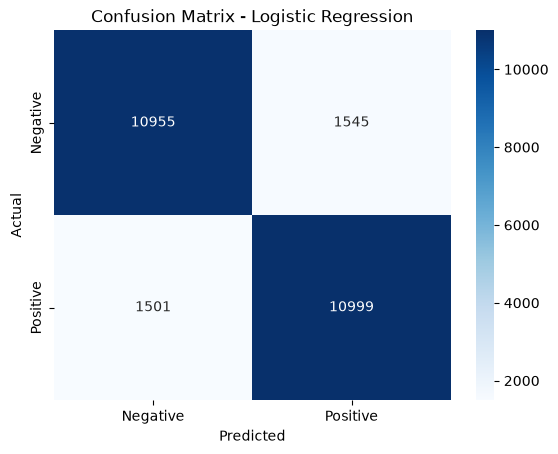

In [6]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [9]:
def predict_sentiment(text):
    clean = re.sub(r'<.*?>', '', text)
    clean = re.sub(r'[^a-zA-Z\s]', '', clean).lower()
    vectorized = tfidf.transform([clean])
    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]
    label = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    print(f"Text: {text}")
    print(f"Sentiment: {label}")
    print(f"Confidence: {max(probability):.2%}\n")

predict_sentiment("This movie was absolutely amazing, I loved every minute of it!")
predict_sentiment("Terrible film, complete waste of time. Very boring and predictable.")
predict_sentiment("It was okay, nothing special but not bad either.")

Text: This movie was absolutely amazing, I loved every minute of it!
Sentiment: POSITIVE 😊
Confidence: 89.57%

Text: Terrible film, complete waste of time. Very boring and predictable.
Sentiment: NEGATIVE 😞
Confidence: 99.97%

Text: It was okay, nothing special but not bad either.
Sentiment: NEGATIVE 😞
Confidence: 99.64%

